# Homework 1 - Task 2: Deblurring (Google Colab)

**Istruzioni:** esegui in ordine; carica `IPPy.zip` e `0.png`. Non richiede astra.

## 1. Dipendenze

In [2]:
!pip install scikit-image -q
print("ok")

ok


## 2. Carica IPPy.zip e 0.png

In [3]:
from google.colab import files
import zipfile, os, shutil
print('Carica IPPy.zip e 0.png ...')
uploaded = files.upload()
for fname in uploaded:
    if fname.endswith('.zip'):
        with zipfile.ZipFile(fname) as z: z.extractall('.')
        print('Estratto:', fname)
if not os.path.isdir('IPPy'):
    for root,dirs,_ in os.walk('.'):
        if 'IPPy' in dirs and os.path.isfile(os.path.join(root,'IPPy','__init__.py')):
            shutil.move(os.path.join(root,'IPPy'),'IPPy'); print('Spostata IPPy da',root); break
assert os.path.isdir('IPPy') and os.path.isfile('0.png'), 'Manca IPPy/ o 0.png'
print('ok:', os.listdir('.'))

Carica IPPy.zip e 0.png ...


Saving 0.png to 0.png
Saving IPPy.zip to IPPy.zip
Estratto: IPPy.zip
ok: ['.config', '0.png', 'IPPy.zip', 'IPPy', 'sample_data']


## 3. Test problem (blur + rumore)

In [4]:
import math, torch
import matplotlib.pyplot as plt
from IPPy import utilities, operators, solvers
from IPPy.utilities import load_image
from IPPy.utilities.metrics import PSNR, SSIM, RE
torch.manual_seed(42)
print("Device:", utilities.get_device())

x_true = load_image('0.png'); print("GT:", list(x_true.shape))
# Operatore di blur gaussiano (varia kernel_size / sigma / noise_level)
kernel_size=11; sigma=1.5; noise_level=0.01
K = operators.Blurring(img_shape=x_true.shape[-2:], kernel_type="gaussian",
                       kernel_size=kernel_size, kernel_variance=sigma**2) #ogni pixel viene "mescolato" con i suoi vicini producendo una sfocatura.
y_delta = K(x_true) + noise_level*torch.randn_like(x_true)#Genera il dato corrotto: prima sfoca l'immagine vera (K(x_true)), poi aggiunge rumore gaussiano.
delta = noise_level*math.sqrt(x_true.numel())#Stima dell'entità del rumore, che servirà al Discrepancy Principle
print("delta =",round(delta,3),"| PSNR blurred =",round(PSNR(y_delta,x_true),2),"dB")

Device: cuda
GT: [1, 1, 256, 256]
delta = 2.56 | PSNR blurred = 25.92 dB


## 4. Solver

In [5]:
# Tikhonov via CGLS ; TV/TpV via Chambolle-Pock
cgls = solvers.CGLS(K)#Nel deblurring l'operatore K (la sfocatura) è una matrice grande e complessa.
#CGLS è un algoritmo molto più efficiente e stabile della discesa di gradiente semplice per questo tipo di problema: converge in molte meno iterazioni e non richiede di scegliere a mano il step
def solve_tikhonov(lam, maxiter=100):
    x,info = cgls(y_delta, x_true=x_true, starting_point=torch.zeros_like(x_true),
                  lam=lam, maxiter=maxiter, tolf=1e-7, tolx=1e-7, verbose=False)
    return x.detach(), info
cp = solvers.ChambollePockTpVUnconstrained(K) #Crea il solver Chambolle-Pock della libreria IPPy. Perché TV e TpV usano la norma L1, che non è differenziabile nel punto zero
def solve_cp(lmbda, p, maxiter=100):#Una sola funzione per entrambi TV e TpV: la differenza è solo il parametro p.
    x,info = cp(y_delta, x_true=x_true, starting_point=torch.zeros_like(x_true),
                lmbda=lmbda, maxiter=maxiter, p=p, verbose=False)
    return x.detach(), info

## 5. Grid search

In [6]:
lambdas = [1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1]#valori piu lati del denoise perchè richiede in genere più regolarizzazione per domare l'amplificazione del rumore.
tau = 1.01
def pc(info): return info["PSNR"][:,0].cpu().numpy().tolist() #Le solite funzioni-aiuto per estrarre PSNR, SSIM e residuo dal "diario"
def sc(info): return info["SSIM"][:,0].cpu().numpy().tolist()
def res(info): return math.sqrt(abs(info["residues"][-1,0].item())) if "residues" in info else float('inf')
def grid(runner): #Per ogni λ della griglia: esegue il metodo, estrae il PSNR massimo e il residuo, e aggiorna i due "vincitori"
    best={"psnr":-1}; dp={"gap":float("inf")}
    for lam in lambdas:
        x,info=runner(lam); pv=max(pc(info)); r=res(info)
        if pv>best["psnr"]: best={"psnr":pv,"lam":lam,"x":x,"info":info} #il λ col PSNR più alto
        g=abs(r-tau*delta)
        if g<dp["gap"]: dp={"gap":g,"lam":lam,"x":x,"info":info,"psnr":pv}#il λ il cui residuo è più vicino a tau*delta
    return best,dp
print("Grid search...")
tk,tk_dp = grid(lambda l: solve_tikhonov(l)); print("Tikhonov done")
tv,tv_dp = grid(lambda l: solve_cp(l,1.0));   print("TV done")
tp,tp_dp = grid(lambda l: solve_cp(l,0.5));   print("TpV done")

Grid search...
Tikhonov done
TV done
TpV done


## 6. Tabella

In [7]:
def rowf(n,d): return f"{n:<22} | {d['lam']:<8.4f} | {d['psnr']:<8.2f} | {max(sc(d['info'])):<6.4f}"
print("="*56)
print(f"{'METODO (criterio)':<22} | {'LAMBDA':<8} | {'PSNR':<8} | SSIM"); print("-"*56)
print(f"{'Blurred':<22} | {'-':<8} | {PSNR(y_delta,x_true):<8.2f} | {SSIM(y_delta,x_true):.4f}")
print(rowf("Tikhonov (best)",tk)); print(rowf("Tikhonov (DP)",tk_dp))
print(rowf("TV p=1 (best)",tv));   print(rowf("TV p=1 (DP)",tv_dp))
print(rowf("TpV p=.5 (best)",tp)); print(rowf("TpV p=.5 (DP)",tp_dp))
print("="*56)

METODO (criterio)      | LAMBDA   | PSNR     | SSIM
--------------------------------------------------------
Blurred                | -        | 25.92    | 0.7768
Tikhonov (best)        | 0.0010   | 30.27    | 0.8662
Tikhonov (DP)          | 0.0010   | 30.27    | 0.8662
TV p=1 (best)          | 0.0100   | 28.97    | 0.8528
TV p=1 (DP)            | 0.0100   | 28.97    | 0.8528
TpV p=.5 (best)        | 0.0050   | 27.61    | 0.7971
TpV p=.5 (DP)          | 0.0100   | 27.38    | 0.7971


## 7. Visualizzazione

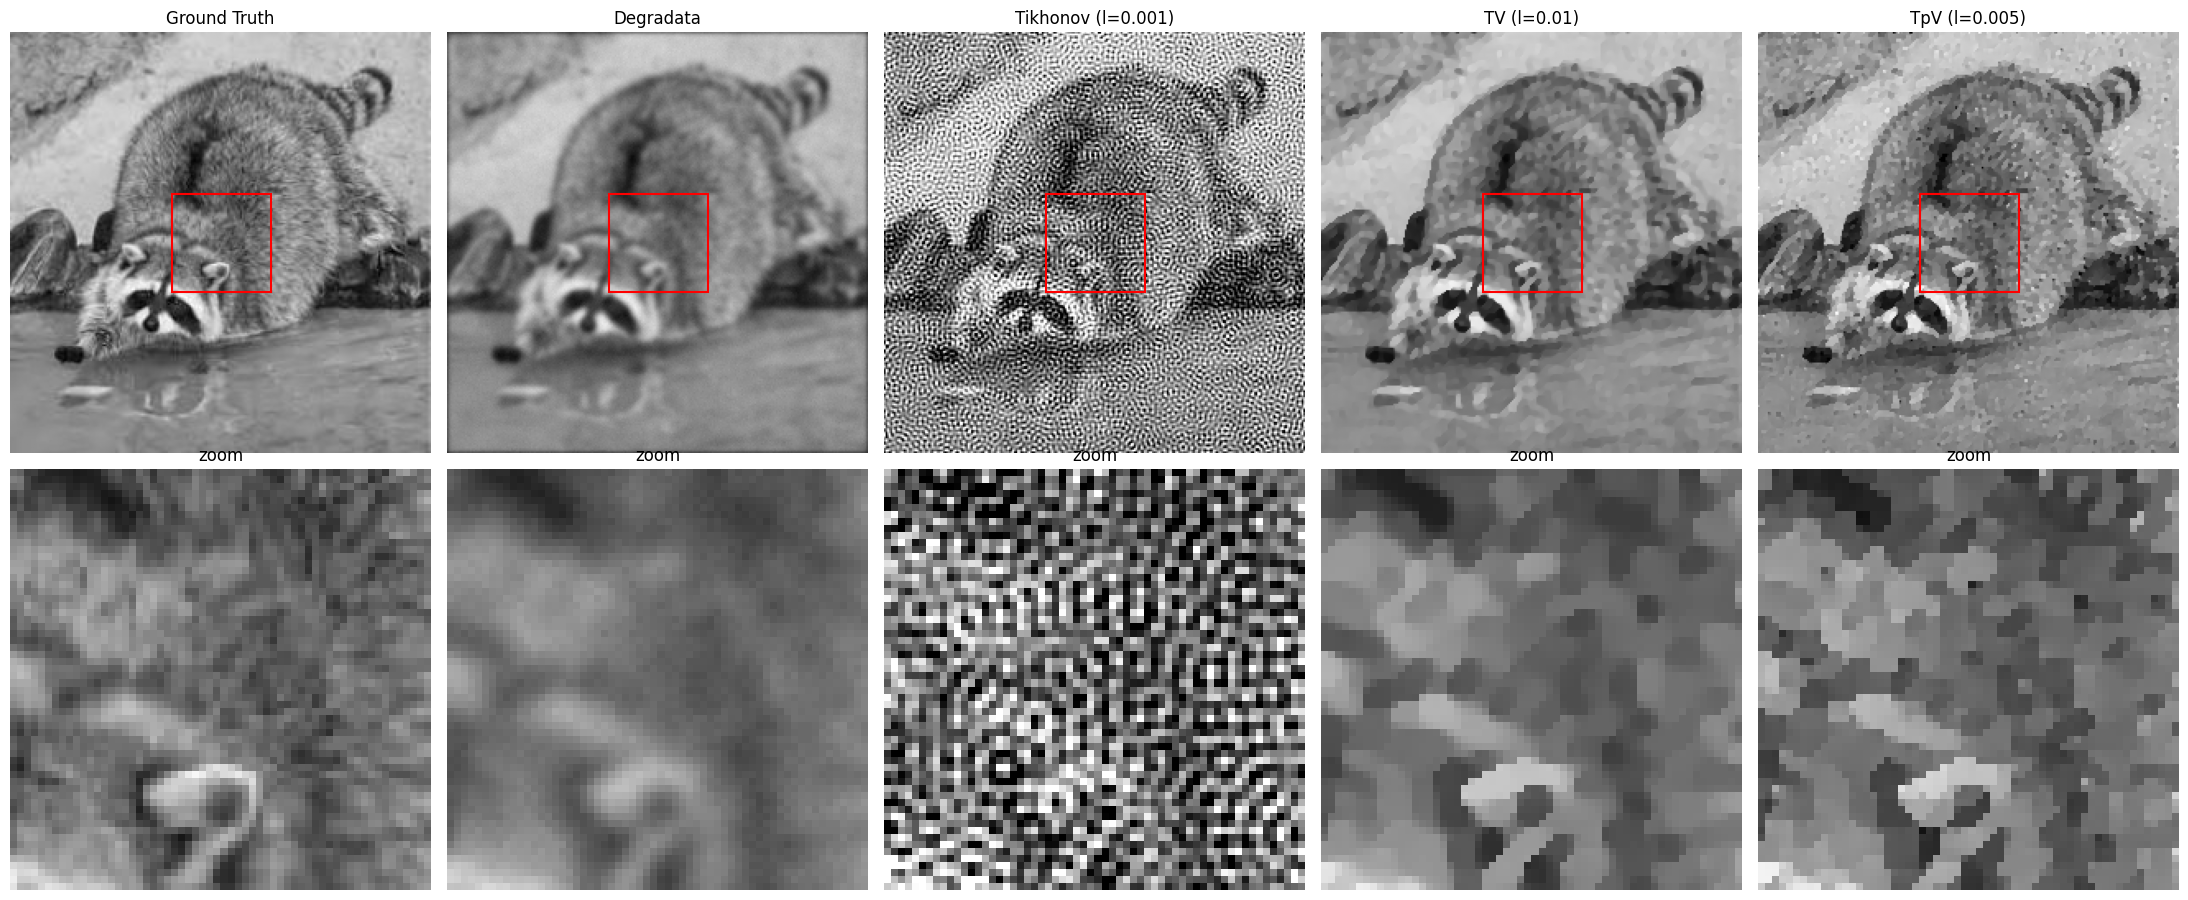

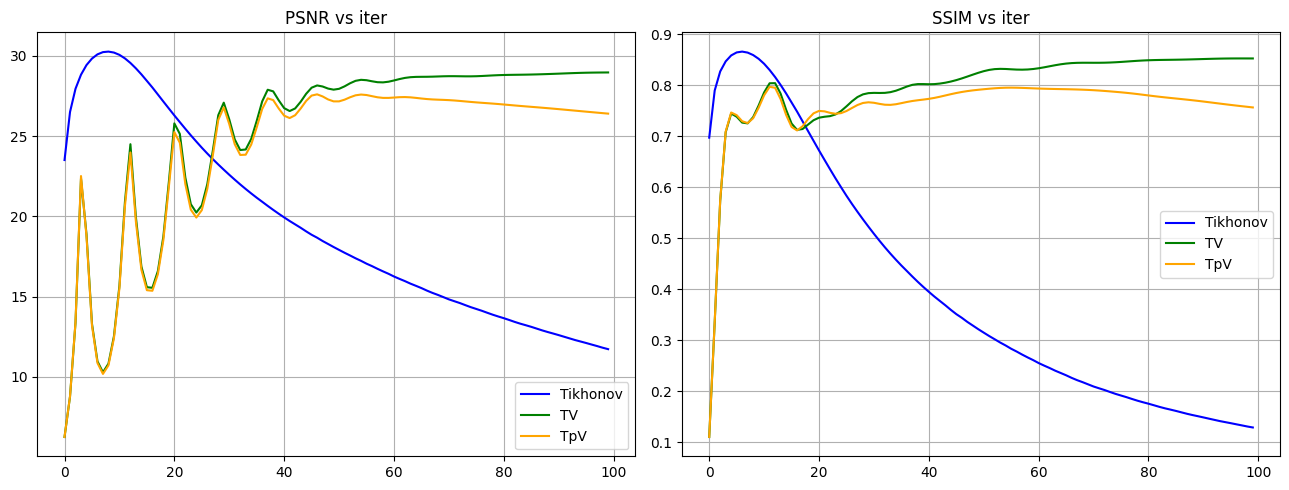

In [8]:
to_np=lambda t:t.detach()[0,0].cpu().numpy()
imgs=[x_true,y_delta,tk["x"],tv["x"],tp["x"]]
titles=["Ground Truth","Degradata",f"Tikhonov (l={tk['lam']})",f"TV (l={tv['lam']})",f"TpV (l={tp['lam']})"]
H=x_true.shape[-1]; a,b=H//2-30,H//2+30
fig,ax=plt.subplots(2,5,figsize=(22,9))
for i,(im,ti) in enumerate(zip(imgs,titles)):
    arr=to_np(im)
    ax[0,i].imshow(arr,cmap='gray',vmin=0,vmax=1); ax[0,i].set_title(ti); ax[0,i].axis('off')
    ax[0,i].add_patch(plt.Rectangle((a,a),b-a,b-a,edgecolor='red',facecolor='none',lw=1.5))
    ax[1,i].imshow(arr[a:b,a:b],cmap='gray',vmin=0,vmax=1); ax[1,i].set_title('zoom'); ax[1,i].axis('off')
plt.tight_layout(); plt.show()
fig,ax=plt.subplots(1,2,figsize=(13,5))
for c,lab,col in [(tk,'Tikhonov','blue'),(tv,'TV','green'),(tp,'TpV','orange')]:
    ax[0].plot(pc(c['info']),label=lab,color=col); ax[1].plot(sc(c['info']),label=lab,color=col)
ax[0].set_title('PSNR vs iter'); ax[0].legend(); ax[0].grid(True)
ax[1].set_title('SSIM vs iter'); ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()